# Obesity-Aware Metabolic Risk Scoring System

## Project Overview

This project develops an explainable machine learning framework for obesity classification and personalized metabolic syndrome risk assessment.

The system combines:
- UCI obesity-related lifestyle and demographic data
- NHANES demographic, examination, laboratory, and questionnaire data
- Machine learning models for obesity classification and metabolic syndrome prediction
- SHAP-based model explainability
- Patient-level probability estimation and risk interpretation

### Project Pipeline

**UCI Obesity Data**
→ Obesity Classification

**NHANES Clinical Data**
→ Metabolic Syndrome Label Construction
→ Metabolic Risk Modeling
→ Probability Estimation
→ SHAP Explanation
→ Individual Patient Interpretation

> **Disclaimer:** This project is intended for educational and research purposes and is not a clinical diagnostic tool.

## 1. Environment and Data Preparation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("/content/drive/MyDrive/obesity_project/Data")        # folder with your 5 CSVs
OUTPUT_DIR = Path("/content/drive/MyDrive/obesity_project/outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

## 2. Stage 1 — Obesity Classification

The first stage uses the UCI obesity dataset to classify individuals into obesity-related categories based on demographic, anthropometric, lifestyle, and behavioral characteristics.

In [3]:
df_uci = pd.read_csv(DATA_DIR /"Stage1.csv")
print(df_uci.shape)
df_uci.head()

(2111, 17)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df_uci["BMI"] = df_uci["Weight"] / (df_uci["Height"] ** 2)

y_raw = df_uci["NObeyesdad"]

X = df_uci.drop(columns=["NObeyesdad"]).copy()

X = X.drop(columns=["BMI"])

binary_cols  = ["FAVC", "SCC", "SMOKE", "family_history_with_overweight"]
ordinal_cols = ["CAEC", "CALC"]
nominal_cols = ["Gender", "MTRANS"]

for col in binary_cols:
    X[col] = X[col].map({"yes": 1, "no": 0})

ord_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
for col in ordinal_cols:
    X[col] = X[col].map(ord_map)

X = pd.get_dummies(X, columns=nominal_cols, drop_first=True, dtype=int)
X.head()

,Age,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,0,0,2.0,3.0,0,0,2.0,1,0.0,1.0,1,0,0,0,1,0
1,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,0,0,0,1,0
2,23.0,1.80,77.0,2,0,2.0,3.0,0,0,2.0,1,2.0,1.0,1,1,0,0,1,0
3,27.0,1.80,87.0,2,0,3.0,3.0,0,0,2.0,0,2.0,0.0,1,1,0,0,0,1
4,22.0,1.78,89.8,1,0,2.0,1.0,0,0,2.0,0,0.0,0.0,1,1,0,0,1,0


In [5]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(1688, 19) (423, 19)


In [6]:
with open(OUTPUT_DIR / "stage1_preprocessed.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "label_encoder": label_encoder,
        "feature_names": list(X_train.columns),
    }, f)

In [7]:
COLUMN_MAP = {
    "demographic": {
        "SEQN": "seqn", "RIDAGEYR": "age", "RIAGENDR": "gender", "RIDRETH3": "race_eth",
    },
    "examination": {
        "SEQN": "seqn",
        "BMXBMI": "bmi", "BMXWT": "weight_kg", "BMXHT": "height_cm", "BMXWAIST": "waist_cm",
        "BPXSY1": "sbp_1", "BPXSY2": "sbp_2", "BPXSY3": "sbp_3",
        "BPXDI1": "dbp_1", "BPXDI2": "dbp_2", "BPXDI3": "dbp_3",
    },
    "labs": {
        "SEQN": "seqn",
        "LBXSGL": "glucose", "LBXGH": "hba1c", "LBXIN": "insulin",
        "LBDHDD": "hdl", "LBDLDL": "ldl", "LBXTC": "total_chol", "LBXTR": "triglycerides",
        "LBXSCR": "creatinine",
        "LBXSATSI": "alt", "LBXSASSI": "ast", "LBXSGTSI": "ggt",
        "LBXSUA": "uric_acid",
    },
    "questionnaire": {
        "SEQN": "seqn",
        "DIQ010": "diabetes_dx", "BPQ020": "hypertension_dx",
        "BPQ080": "high_chol_dx", "MCQ160C": "chd_dx", "MCQ160E": "heart_attack_dx",
    },
}

def load_subset(filename, col_dict):
    df = pd.read_csv(DATA_DIR / f"{filename}.csv", usecols=list(col_dict.keys()))
    return df.rename(columns=col_dict)

In [8]:
demo  = load_subset("demographic",   COLUMN_MAP["demographic"])
exam  = load_subset("examination",   COLUMN_MAP["examination"])
labs  = load_subset("labs",          COLUMN_MAP["labs"])
quest = load_subset("questionnaire", COLUMN_MAP["questionnaire"])

df = demo.merge(exam, on="seqn", how="inner")
df = df.merge(labs,  on="seqn", how="left")
df = df.merge(quest, on="seqn", how="left")
print(df.shape)

(9813, 31)


In [9]:
# Average 3 BP readings
df["sbp"] = df[["sbp_1", "sbp_2", "sbp_3"]].mean(axis=1)
df["dbp"] = df[["dbp_1", "dbp_2", "dbp_3"]].mean(axis=1)
df = df.drop(columns=["sbp_1","sbp_2","sbp_3","dbp_1","dbp_2","dbp_3"])

# Decode gender
df["gender"] = df["gender"].map({1: "Male", 2: "Female"})

# Adults only
df = df[df["age"] >= 18].reset_index(drop=True)
print(df.shape)

(5924, 27)


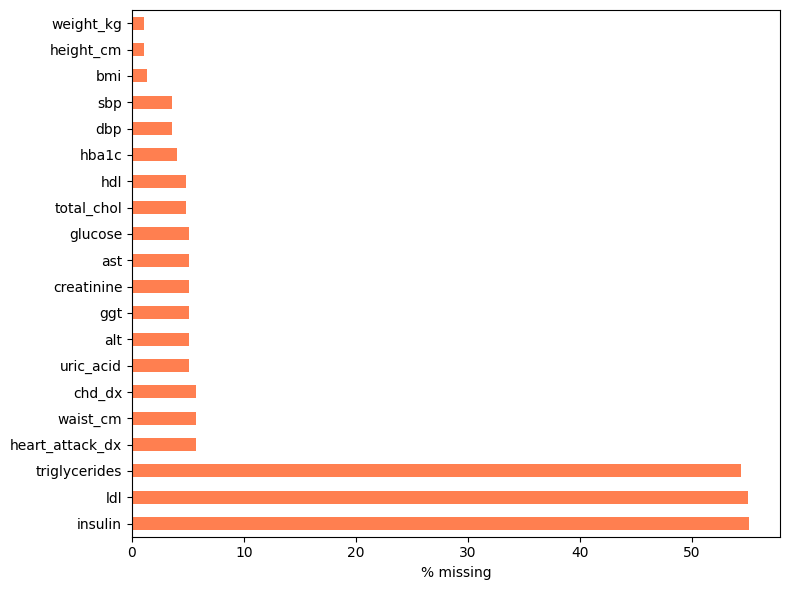

,0
insulin,55.1
ldl,55.0
triglycerides,54.4
heart_attack_dx,5.7
waist_cm,5.7
chd_dx,5.7
uric_acid,5.1
alt,5.1
ggt,5.1
creatinine,5.1


In [10]:
miss = (df.isna().sum() / len(df) * 100).round(1).sort_values(ascending=False)
miss[miss > 0].plot(kind="barh", figsize=(8,6), color="coral")
plt.xlabel("% missing"); plt.tight_layout(); plt.show()
miss

## 3. NHANES Data Integration

The second stage integrates selected demographic, examination, laboratory, and questionnaire variables from NHANES to construct a clinical dataset for metabolic risk analysis.

In [11]:
df.to_csv(OUTPUT_DIR / "nhanes_clean.csv", index=False)
print(df.shape)
df.head()

(5924, 27)


,seqn,gender,age,race_eth,weight_kg,height_cm,bmi,waist_cm,ast,alt,...,triglycerides,ldl,total_chol,hypertension_dx,high_chol_dx,diabetes_dx,chd_dx,heart_attack_dx,sbp,dbp
0,73557,Male,69,4,78.3,171.3,26.7,100.0,16.0,16.0,...,NaN,NaN,167.0,1.0,1.0,1.0,2.0,2.0,112.666667,74.000000
1,73558,Male,54,3,89.5,176.8,28.6,107.6,18.0,29.0,...,NaN,NaN,170.0,1.0,1.0,1.0,2.0,2.0,157.333333,61.333333
2,73559,Male,72,3,88.9,175.3,28.9,109.2,22.0,16.0,...,51.0,56.0,126.0,1.0,1.0,1.0,2.0,2.0,142.000000,82.000000
3,73561,Female,73,3,52.0,162.4,19.7,NaN,36.0,28.0,...,75.0,101.0,201.0,1.0,2.0,2.0,2.0,2.0,137.333333,86.666667
4,73562,Male,56,1,105.0,158.7,41.7,123.1,24.0,16.0,...,NaN,NaN,226.0,1.0,1.0,2.0,1.0,1.0,157.333333,82.000000


In [12]:
with open(OUTPUT_DIR / "stage1_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
label_encoder   = data["label_encoder"]
feature_names   = data["feature_names"]
class_names     = label_encoder.classes_

print(X_train.shape, X_test.shape)

(1688, 19) (423, 19)


## 4. Stage 1 Model Training and Evaluation

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import seaborn as sns

In [14]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest":       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost":            XGBClassifier(n_estimators=300, learning_rate=0.1,
                                        random_state=42, eval_metric="mlogloss"),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="f1_macro", n_jobs=-1)
    results[name] = scores
    print(f"{name:20s} F1-macro: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression   F1-macro: 0.8323 (+/- 0.0198)
RandomForest         F1-macro: 0.9489 (+/- 0.0143)
XGBoost              F1-macro: 0.9619 (+/- 0.0155)


In [15]:
best_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
print(f"Test accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1-macro:  {f1_score(y_test, y_pred, average='macro'):.4f}")

Test accuracy:  0.9504
Test F1-macro:  0.9495


In [16]:
train_pred = best_model.predict(X_train)
print(f"Train F1-macro: {f1_score(y_train, train_pred, average='macro'):.4f}")
print(f"Test F1-macro:  {f1_score(y_test, y_pred, average='macro'):.4f}")

Train F1-macro: 1.0000
Test F1-macro:  0.9495


### Train–Test Performance Check

The small difference between training and held-out test performance suggests that the model does not exhibit substantial overfitting on this split.

Further validation using cross-validation and evaluation on independent data would be required for stronger evidence of generalization.

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.93      0.94        54
      Normal_Weight       0.83      0.95      0.89        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.88      0.91        58
Overweight_Level_II       0.97      0.97      0.97        58

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



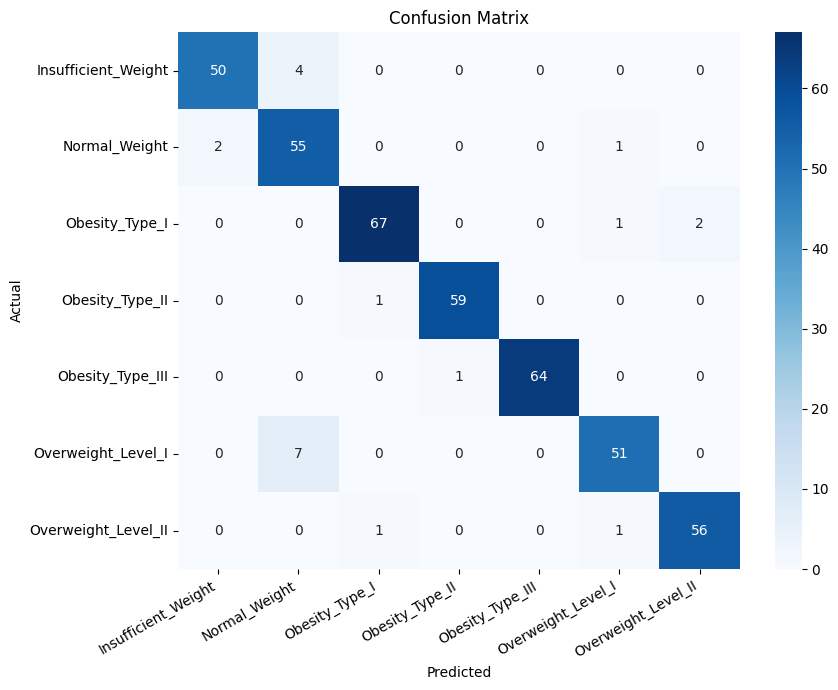

In [17]:
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

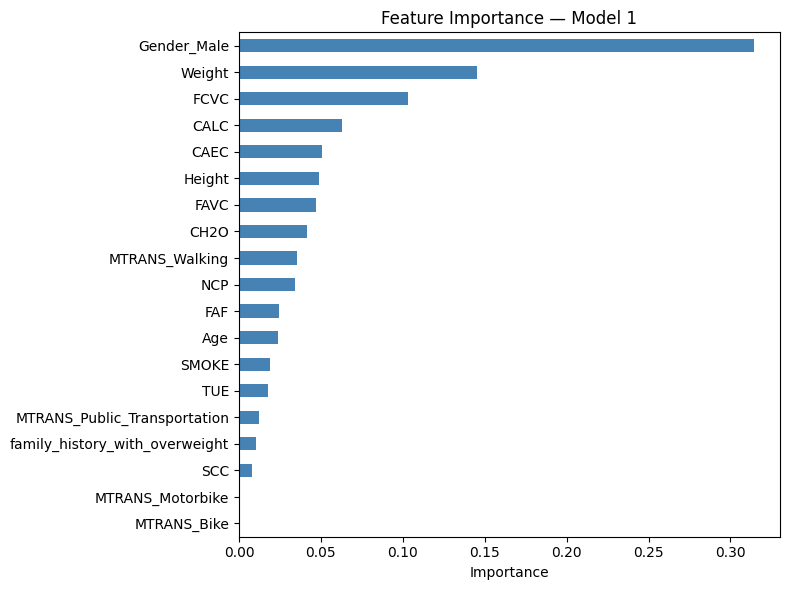

In [18]:
importances = pd.Series(best_model.feature_importances_, index=feature_names)
importances.sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Feature Importance — Model 1"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()

In [19]:
with open(OUTPUT_DIR / "model1_obesity_classifier.pkl", "wb") as f:
    pickle.dump({
        "model": best_model,
        "label_encoder": label_encoder,
        "feature_names": feature_names,
    }, f)
print("Saved Model 1")

Saved Model 1


In [20]:
df = pd.read_csv(OUTPUT_DIR / "nhanes_clean.csv")

with open(OUTPUT_DIR / "model1_obesity_classifier.pkl", "rb") as f:
    m1 = pickle.load(f)
model1        = m1["model"]
m1_features   = m1["feature_names"]
m1_encoder    = m1["label_encoder"]

print(df.shape)

(5924, 27)


In [21]:
required = ["waist_cm", "triglycerides", "hdl", "sbp", "dbp", "glucose",
            "hba1c", "insulin", "ldl", "total_chol", "alt", "ast",
            "ggt", "creatinine", "uric_acid", "bmi", "height_cm", "weight_kg"]

df_f = df.dropna(subset=required).reset_index(drop=True)
print(f"Fasted subsample with full panel: {df_f.shape}")

Fasted subsample with full panel: (2422, 27)


In [22]:
df_f["mets_waist"] = (((df_f["gender"] == "Male")   & (df_f["waist_cm"] >= 102)) |
                      ((df_f["gender"] == "Female") & (df_f["waist_cm"] >= 88)))
df_f["mets_tg"]    = df_f["triglycerides"] >= 150
df_f["mets_hdl"]   = (((df_f["gender"] == "Male")   & (df_f["hdl"] < 40)) |
                      ((df_f["gender"] == "Female") & (df_f["hdl"] < 50)))
df_f["mets_bp"]    = (df_f["sbp"] >= 130) | (df_f["dbp"] >= 85)
df_f["mets_glu"]   = df_f["glucose"] >= 100

mets_flags = ["mets_waist", "mets_tg", "mets_hdl", "mets_bp", "mets_glu"]
df_f["mets_count"] = df_f[mets_flags].sum(axis=1)
df_f["mets"]       = (df_f["mets_count"] >= 3).astype(int)

print("MetS prevalence:", df_f["mets"].mean().round(3))
print(df_f["mets"].value_counts())

MetS prevalence: 0.264
mets
0    1782
1     640
Name: count, dtype: int64


In [23]:
# Construct a frame with the exact columns Model 1 expects.
# Available in NHANES: age, height (m), weight, gender, BMI.
# Missing lifestyle features -> fill with training-set mode.

nhanes_for_m1 = pd.DataFrame(index=df_f.index)
nhanes_for_m1["Age"]    = df_f["age"]
nhanes_for_m1["Height"] = df_f["height_cm"] / 100.0   # UCI uses meters
nhanes_for_m1["Weight"] = df_f["weight_kg"]
nhanes_for_m1["BMI"]    = df_f["bmi"]
nhanes_for_m1["Gender_Male"] = (df_f["gender"] == "Male").astype(int)

# Fill missing lifestyle features with training-set mode
train_mode = m1["model"].feature_names_in_  # just to get names
X_train_ref = pd.read_pickle  # we need access; reload from pkl
with open(OUTPUT_DIR / "stage1_preprocessed.pkl", "rb") as f:
    stage1_data = pickle.load(f)
mode_values = stage1_data["X_train"].mode().iloc[0]

for col in m1_features:
    if col not in nhanes_for_m1.columns:
        nhanes_for_m1[col] = mode_values[col]

# Reorder to match training order exactly
nhanes_for_m1 = nhanes_for_m1[m1_features]
print(nhanes_for_m1.shape)
nhanes_for_m1.head()

(2422, 19)


,Age,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,72,1.753,88.9,1.0,1.0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,1,0.0,0.0,1.0,0.0
1,61,1.618,93.4,1.0,1.0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0
2,26,1.525,47.1,1.0,1.0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0
3,33,1.580,56.8,1.0,1.0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0
4,32,1.662,79.7,1.0,1.0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,1,0.0,0.0,1.0,0.0


In [24]:
obesity_pred = model1.predict(nhanes_for_m1)
df_f["obesity_label"] = m1_encoder.inverse_transform(obesity_pred)

print(df_f["obesity_label"].value_counts())

obesity_label
Normal_Weight          704
Obesity_Type_I         501
Overweight_Level_I     453
Overweight_Level_II    423
Obesity_Type_III       155
Obesity_Type_II        131
Insufficient_Weight     55
Name: count, dtype: int64


### Preventing Target Leakage

Metabolic syndrome is defined using five clinical criteria. To prevent target leakage, the variables directly used to construct the MetS label are excluded from the model's predictive feature set.

The model instead uses related demographic, anthropometric, biochemical, and clinical measurements that are not directly used to define the target.

This allows the model to learn associations with metabolic syndrome rather than simply reproducing the rule used to construct the label.

In [25]:
# Features: explicitly EXCLUDE the 5 variables used to define MetS label
# (waist_cm, triglycerides, hdl, sbp, dbp, glucose) to avoid target leakage.
biomarker_features = [
    "age", "gender", "bmi",
    "hba1c", "insulin",
    "ldl", "total_chol",
    "alt", "ast", "ggt",
    "creatinine", "uric_acid",
    "obesity_label",
]

X2 = df_f[biomarker_features].copy()
y2 = df_f["mets"].values

X2["gender"] = (X2["gender"] == "Male").astype(int)
X2 = pd.get_dummies(X2, columns=["obesity_label"], drop_first=True, dtype=int)

print(X2.shape)
X2.head()

(2422, 18)


,age,gender,bmi,hba1c,insulin,ldl,total_chol,alt,ast,ggt,creatinine,uric_acid,obesity_label_Normal_Weight,obesity_label_Obesity_Type_I,obesity_label_Obesity_Type_II,obesity_label_Obesity_Type_III,obesity_label_Overweight_Level_I,obesity_label_Overweight_Level_II
0,72,1,28.9,8.9,5.83,56.0,126.0,16.0,22.0,13.0,1.22,5.7,0,0,0,0,0,1
1,61,0,35.7,5.5,14.91,97.0,168.0,21.0,20.0,17.0,0.92,5.1,0,1,0,0,0,0
2,26,0,20.3,5.2,3.85,67.0,168.0,23.0,20.0,13.0,0.74,4.5,1,0,0,0,0,0
3,33,0,22.8,5.0,6.05,75.0,131.0,20.0,20.0,21.0,0.59,2.7,1,0,0,0,0,0
4,32,1,28.9,5.3,16.15,119.0,182.0,44.0,30.0,30.0,0.68,6.1,0,0,0,0,0,1


## 5. Stage 2 — Metabolic Syndrome Risk Modeling

In [26]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, stratify=y2, random_state=42
)
print(X2_train.shape, X2_test.shape)

(1937, 18) (485, 18)


In [27]:
models2 = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest":       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost":            XGBClassifier(n_estimators=300, learning_rate=0.1,
                                        random_state=42, eval_metric="logloss"),
}

for name, model in models2.items():
    scores = cross_val_score(model, X2_train, y2_train, cv=5,
                             scoring="roc_auc", n_jobs=-1)
    print(f"{name:20s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression   ROC-AUC: 0.8446 (+/- 0.0288)
RandomForest         ROC-AUC: 0.8460 (+/- 0.0205)
XGBoost              ROC-AUC: 0.8250 (+/- 0.0247)


### Model Comparison

Three classification approaches were evaluated using 5-fold cross-validation with ROC-AUC as the primary evaluation metric.

| Model | Mean ROC-AUC | Standard Deviation |
|---|---:|---:|
| Logistic Regression | 0.8446 | ±0.0288 |
| **Random Forest** | **0.8460** | **±0.0205** |
| XGBoost | 0.8250 | ±0.0247 |

Random Forest achieved the highest mean ROC-AUC and the lowest standard deviation among the evaluated models, indicating the strongest and most consistent cross-validation performance.

The Random Forest model was therefore selected as the final metabolic syndrome classifier.

In [28]:
best_model2 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
best_model2.fit(X2_train, y2_train)

y2_pred  = best_model2.predict(X2_test)
y2_proba = best_model2.predict_proba(X2_test)[:, 1]

from sklearn.metrics import roc_auc_score
print(f"Test accuracy: {accuracy_score(y2_test, y2_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y2_test, y2_proba):.4f}")
print()
print(classification_report(y2_test, y2_pred, target_names=["No MetS", "MetS"]))

Test accuracy: 0.7979
Test ROC-AUC:  0.8507

              precision    recall  f1-score   support

     No MetS       0.83      0.91      0.87       357
        MetS       0.66      0.48      0.55       128

    accuracy                           0.80       485
   macro avg       0.75      0.69      0.71       485
weighted avg       0.79      0.80      0.79       485



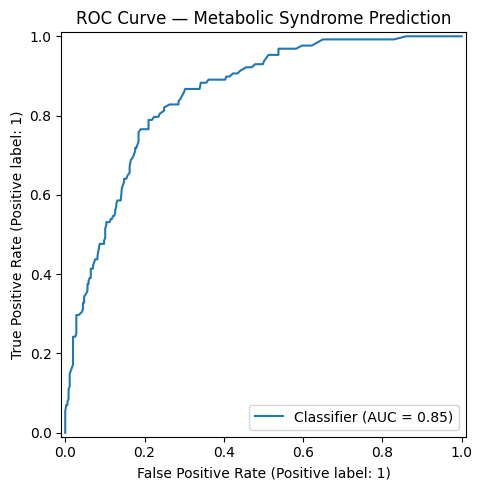

In [29]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y2_test,
    y2_proba,
    ax=ax
)

ax.set_title("ROC Curve — Metabolic Syndrome Prediction")
plt.tight_layout()
plt.show()

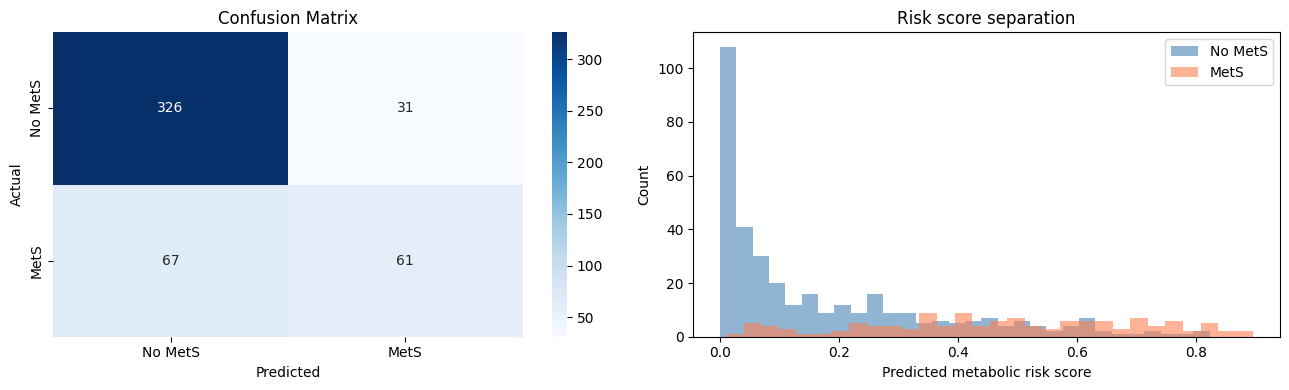

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm2 = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No MetS","MetS"], yticklabels=["No MetS","MetS"], ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Confusion Matrix")

axes[1].hist(y2_proba[y2_test==0], bins=30, alpha=0.6, label="No MetS", color="steelblue")
axes[1].hist(y2_proba[y2_test==1], bins=30, alpha=0.6, label="MetS",    color="coral")
axes[1].set_xlabel("Predicted metabolic risk score")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk score separation")
axes[1].legend()
plt.tight_layout(); plt.show()

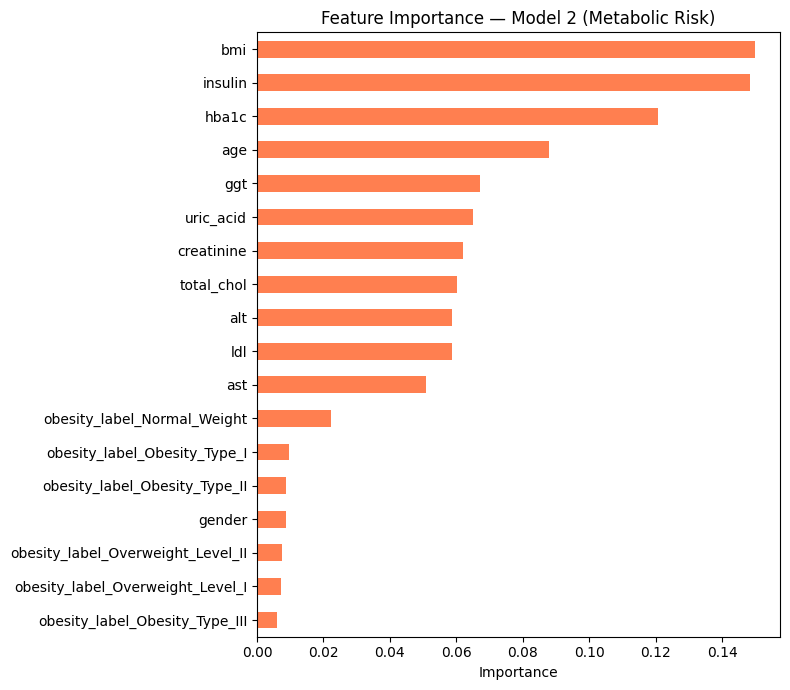

In [31]:
importances2 = pd.Series(best_model2.feature_importances_, index=X2.columns)
importances2.sort_values().plot(kind="barh", figsize=(8, 7), color="coral")
plt.title("Feature Importance — Model 2 (Metabolic Risk)"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()

In [32]:
with open(OUTPUT_DIR / "model2_metabolic_risk.pkl", "wb") as f:
    pickle.dump({
        "model": best_model2,
        "feature_names": list(X2.columns),
        "mets_criteria": mets_flags,
    }, f)
print("Saved Model 2")

Saved Model 2


## 6. Explainable AI with SHAP

### Global Feature Importance

SHAP (SHapley Additive exPlanations) is used to understand how individual features influence the metabolic syndrome classifier.

The global SHAP summary below ranks features according to their overall contribution to model predictions across the test dataset.

Higher absolute SHAP values indicate a greater influence on the model output, while the feature color represents the relative feature value.

In [35]:
import shap
# TreeExplainer is fast for tree-based models (Random Forest, XGBoost)
explainer = shap.TreeExplainer(best_model2)
shap_values = explainer.shap_values(X2_test)

# For binary classification, RF returns a list [class_0_shap, class_1_shap]
# or a 3D array depending on SHAP version. Grab class 1 (MetS).
if isinstance(shap_values, list):
    shap_vals_mets = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals_mets = shap_values[:, :, 1]
else:
    shap_vals_mets = shap_values

print("SHAP values shape:", shap_vals_mets.shape)

SHAP values shape: (485, 18)


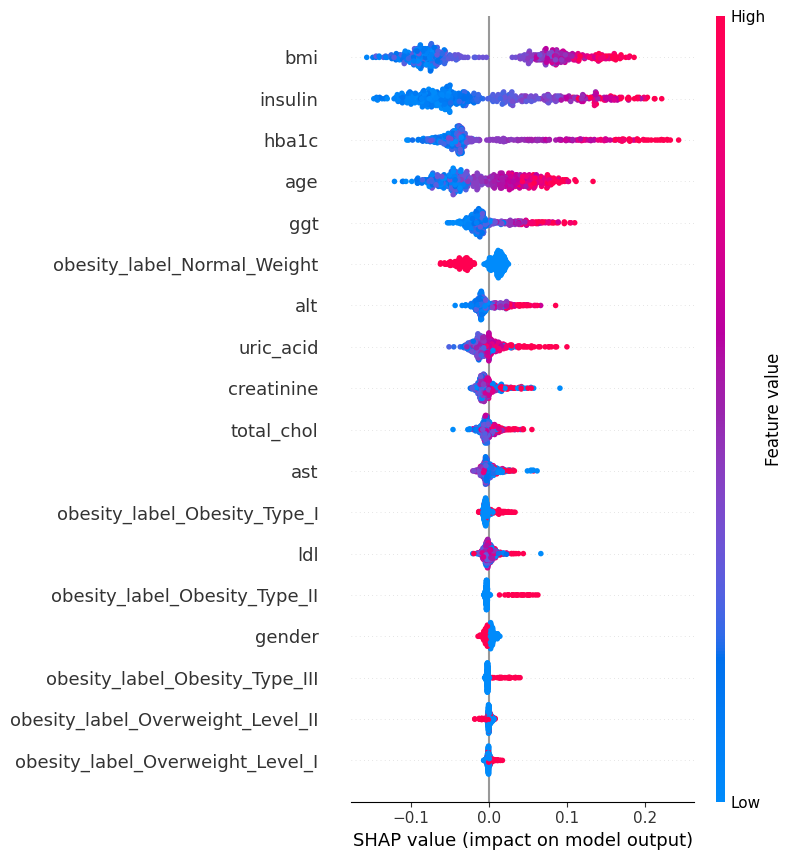

In [36]:
# Summary plot = feature importance + direction of effect
shap.summary_plot(shap_vals_mets, X2_test, show=True)

### Individual Prediction Explanation

SHAP is also used to explain predictions for individual patients.

The waterfall plot below shows how each feature shifts the model output from the expected baseline prediction toward the final predicted probability for the selected patient.

Positive contributions increase the predicted probability, while negative contributions decrease it.

Predicted metabolic syndrome probability: 0.897
Actual MetS label:  1

Patient features:
age                                   50.00
gender                                 0.00
bmi                                   41.60
hba1c                                  8.20
insulin                               23.70
ldl                                   84.00
total_chol                           157.00
alt                                   28.00
ast                                   19.00
ggt                                   24.00
creatinine                             0.76
uric_acid                              5.70
obesity_label_Normal_Weight            0.00
obesity_label_Obesity_Type_I           0.00
obesity_label_Obesity_Type_II          0.00
obesity_label_Obesity_Type_III         1.00
obesity_label_Overweight_Level_I       0.00
obesity_label_Overweight_Level_II      0.00
Name: 73, dtype: float64


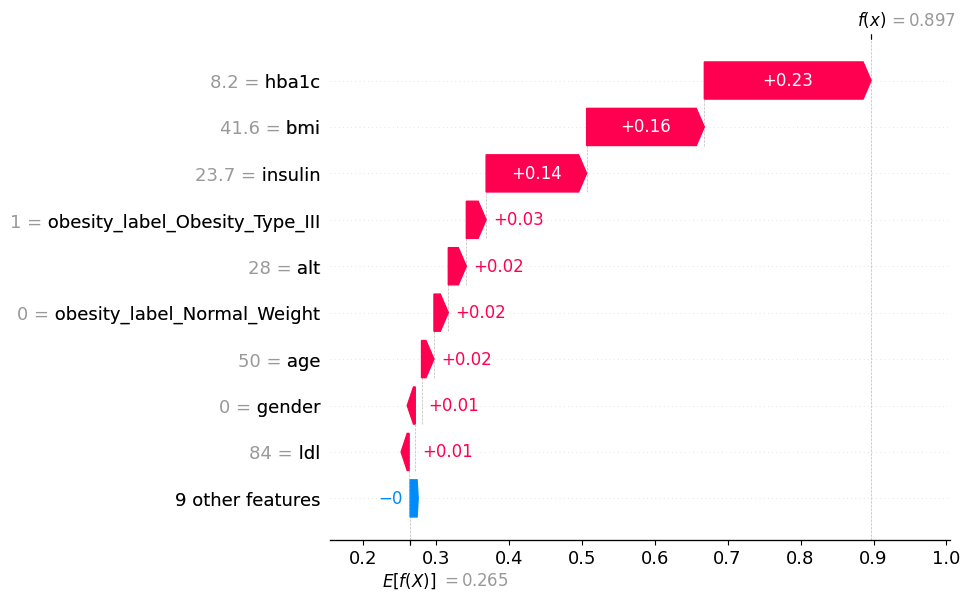

In [37]:
# Pick a high-risk patient from the test set
high_risk_idx = np.argmax(y2_proba)
patient_features = X2_test.iloc[high_risk_idx]
patient_risk     = y2_proba[high_risk_idx]

print(f"Predicted metabolic syndrome probability: {patient_risk:.3f}")
print(f"Actual MetS label:  {y2_test[high_risk_idx]}")
print("\nPatient features:")
print(patient_features)

# Waterfall plot: exactly which features pushed this patient's risk up/down
shap.plots.waterfall(shap.Explanation(
    values        = shap_vals_mets[high_risk_idx],
    base_values   = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data          = patient_features.values,
    feature_names = X2_test.columns.tolist(),
))

In [38]:
def predict_metabolic_risk(patient):
    """
    Take raw patient measurements, return metabolic risk score + explanation.

    patient: dict with these keys
        age (years), gender ("Male"/"Female"),
        height_cm, weight_kg,
        hba1c (%), insulin (uU/mL),
        ldl, total_chol (mg/dL),
        alt, ast, ggt (U/L),
        creatinine, uric_acid (mg/dL)

    Returns: dict with risk_score, obesity_class, top_risk_factors
    """
    # --- Step 1: Run Model 1 to get obesity classification ---
    bmi = patient["weight_kg"] / ((patient["height_cm"] / 100) ** 2)

    m1_input = pd.DataFrame([{c: mode_values[c] for c in m1_features}])
    m1_input["Age"]         = patient["age"]
    m1_input["Height"]      = patient["height_cm"] / 100
    m1_input["Weight"]      = patient["weight_kg"]
    m1_input["BMI"]         = bmi
    m1_input["Gender_Male"] = 1 if patient["gender"] == "Male" else 0
    m1_input = m1_input[m1_features]

    obesity_pred  = model1.predict(m1_input)[0]
    obesity_label = m1_encoder.inverse_transform([obesity_pred])[0]

    # --- Step 2: Build Model 2 input ---
    m2_row = {
        "age": patient["age"],
        "gender": 1 if patient["gender"] == "Male" else 0,
        "bmi": bmi,
        "hba1c": patient["hba1c"],
        "insulin": patient["insulin"],
        "ldl": patient["ldl"],
        "total_chol": patient["total_chol"],
        "alt": patient["alt"],
        "ast": patient["ast"],
        "ggt": patient["ggt"],
        "creatinine": patient["creatinine"],
        "uric_acid": patient["uric_acid"],
    }
    # Add one-hot columns for obesity_label (match training columns)
    for col in X2.columns:
        if col.startswith("obesity_label_"):
            m2_row[col] = 1 if col == f"obesity_label_{obesity_label}" else 0

    m2_input = pd.DataFrame([m2_row])[X2.columns]   # enforce column order

    # --- Step 3: Predict ---
    risk_score = best_model2.predict_proba(m2_input)[0, 1]

    # --- Step 4: SHAP explanation for THIS patient ---
    sv = explainer.shap_values(m2_input)
    sv = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if sv.ndim == 3 else sv)
    contribs = pd.Series(sv[0], index=X2.columns).sort_values(key=abs, ascending=False)
    top_factors = contribs.head(5).to_dict()

    return {
        "risk_score":      round(float(risk_score), 3),
        "obesity_class":   obesity_label,
        "bmi":             round(bmi, 1),
        "top_risk_factors": {k: round(v, 4) for k, v in top_factors.items()},
    }

## 7. Individual Patient Risk Interpretation

In [39]:
# Example: middle-aged man with borderline metabolic markers
example_patient = {
    "age": 52, "gender": "Male",
    "height_cm": 175, "weight_kg": 95,
    "hba1c": 6.1, "insulin": 22,
    "ldl": 140, "total_chol": 220,
    "alt": 45, "ast": 32, "ggt": 60,
    "creatinine": 1.0, "uric_acid": 6.8,
}

result = predict_metabolic_risk(example_patient)
print(f"Risk score:     {result['risk_score']}")
print(f"Obesity class:  {result['obesity_class']}")
print(f"BMI:            {result['bmi']}")
print(f"\nTop contributing factors (positive = raises risk, negative = lowers):")
for feature, contribution in result["top_risk_factors"].items():
    arrow = "↑" if contribution > 0 else "↓"
    print(f"  {arrow} {feature:<20s} {contribution:+.4f}")

Risk score:     0.67
Obesity class:  Overweight_Level_II
BMI:            31.0

Top contributing factors (positive = raises risk, negative = lowers):
  ↑ insulin              +0.1312
  ↑ hba1c                +0.1115
  ↑ bmi                  +0.0953
  ↑ ggt                  +0.0521
  ↑ alt                  +0.0239


## 8. Interactive Prediction Interface

In [40]:
SAMPLE_PROFILES = {
    "— Custom —": None,

    "🟢 Normal weight, low risk (expected)": {
        # BMI ~22, clean biomarkers — the "textbook healthy" baseline
        "age": 28, "gender": "Male", "height_cm": 178, "weight_kg": 70,
        "hba1c": 5.1, "insulin": 6.0, "ldl": 95, "total_chol": 170,
        "alt": 22, "ast": 20, "ggt": 18, "creatinine": 1.0, "uric_acid": 5.2,
    },

    "🔴 Obese, high risk (expected)": {
        # BMI ~33, elevated biomarkers across the board — the "textbook unhealthy" case
        "age": 55, "gender": "Male", "height_cm": 175, "weight_kg": 102,
        "hba1c": 6.8, "insulin": 28, "ldl": 155, "total_chol": 245,
        "alt": 55, "ast": 40, "ggt": 75, "creatinine": 1.1, "uric_acid": 7.2,
    },

    "⚠️ TOFI — normal BMI, high risk": {
        # BMI ~23, but insulin resistance + diabetic HbA1c + dyslipidemia
        # "Thin Outside, Fat Inside" — visceral fat phenotype
        "age": 50, "gender": "Female", "height_cm": 163, "weight_kg": 60,
        "hba1c": 7.0, "insulin": 20, "ldl": 148, "total_chol": 225,
        "alt": 38, "ast": 32, "ggt": 55, "creatinine": 0.85, "uric_acid": 5.9,
    },

    "✨ MHO — obese, low risk": {
        # BMI ~33 but pristine biomarkers — "Metabolically Healthy Obese"
        # Uncommon but real phenotype; some people carry weight without metabolic dysfunction
        "age": 35, "gender": "Female", "height_cm": 165, "weight_kg": 90,
        "hba1c": 5.2, "insulin": 8.0, "ldl": 100, "total_chol": 175,
        "alt": 24, "ast": 22, "ggt": 20, "creatinine": 0.9, "uric_acid": 5.0,
    },
}

In [49]:
def gradio_predict(age, gender, height_cm, weight_kg,
                   hba1c, insulin, ldl, total_chol,
                   alt, ast, ggt, creatinine, uric_acid):

    patient = dict(
        age=age,
        gender=gender,
        height_cm=height_cm,
        weight_kg=weight_kg,
        hba1c=hba1c,
        insulin=insulin,
        ldl=ldl,
        total_chol=total_chol,
        alt=alt,
        ast=ast,
        ggt=ggt,
        creatinine=creatinine,
        uric_acid=uric_acid
    )

    result = predict_metabolic_risk(patient)

    # Predicted metabolic syndrome probability
    score = result["risk_score"]
    probability_pct = score * 100

    # HTML card for probability display
    score_html = f"""
    <div style='text-align:center; padding:24px;
                background:#6366f115;
                border:2px solid #6366f1;
                border-radius:14px;'>

      <div style='font-size:17px; color:#555; margin-bottom:8px;'>
        Predicted Metabolic Syndrome Probability
      </div>

      <div style='font-size:52px; font-weight:bold; color:#6366f1;'>
        {probability_pct:.1f}%
      </div>

      <div style='margin-top:10px; color:#555; font-size:15px;'>
        Model probability: {score:.3f}
      </div>

      <div style='margin-top:12px; color:#555;'>
        BMI: {result['bmi']}
        &nbsp;|&nbsp;
        Predicted obesity class: {result['obesity_class']}
      </div>

    </div>
    """

    # Top contributing factors
    factors_md = "### Top Factors Influencing This Prediction\n\n"
    factors_md += "| Feature | Contribution | Direction |\n"
    factors_md += "|---|---:|---|\n"

    for feat, contrib in result["top_risk_factors"].items():

        if contrib > 0:
            direction = "↑ increases predicted probability"
        else:
            direction = "↓ decreases predicted probability"

        factors_md += (
            f"| `{feat}` | {contrib:+.4f} | {direction} |\n"
        )

    return score_html, factors_md


def load_profile(profile_name):
    """Fill sliders from a selected preset."""

    p = SAMPLE_PROFILES.get(profile_name)

    if p is None:
        return [gr.update()] * 13

    return [
        p["age"],
        p["gender"],
        p["height_cm"],
        p["weight_kg"],
        p["hba1c"],
        p["insulin"],
        p["ldl"],
        p["total_chol"],
        p["alt"],
        p["ast"],
        p["ggt"],
        p["creatinine"],
        p["uric_acid"]
    ]

In [50]:
import gradio as gr

with gr.Blocks(
    title="Obesity-Aware Metabolic Risk Predictor",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown(
        "# 🩺 Obesity-Aware Metabolic Risk Predictor\n"
        "Two-stage machine learning pipeline combining obesity classification "
        "with metabolic syndrome probability estimation.\n\n"
        "Adjust the patient's values below or select an example profile to "
        "explore the model's prediction and explanation."
    )

    # Sample profile selector
    with gr.Row():
        profile_dd = gr.Dropdown(
            choices=list(SAMPLE_PROFILES.keys()),
            value="— Custom —",
            label="📋 Load Sample Profile"
        )

    with gr.Row():

        # =========================
        # LEFT: INPUTS
        # =========================
        with gr.Column(scale=1):

            gr.Markdown("### Demographics & Body")

            age = gr.Slider(
                18, 80,
                value=45,
                step=1,
                label="Age"
            )

            gender = gr.Radio(
                ["Male", "Female"],
                value="Male",
                label="Gender"
            )

            height_cm = gr.Slider(
                140, 200,
                value=170,
                step=1,
                label="Height (cm)"
            )

            weight_kg = gr.Slider(
                40, 150,
                value=75,
                step=1,
                label="Weight (kg)"
            )

            gr.Markdown("### Glucose Metabolism")

            hba1c = gr.Slider(
                4.0, 10.0,
                value=5.5,
                step=0.1,
                label="HbA1c (%)"
            )

            insulin = gr.Slider(
                1.0, 50.0,
                value=10,
                step=0.5,
                label="Insulin (uU/mL)"
            )

            gr.Markdown("### Lipids")

            ldl = gr.Slider(
                50, 250,
                value=120,
                step=1,
                label="LDL (mg/dL)"
            )

            total_chol = gr.Slider(
                100, 350,
                value=190,
                step=1,
                label="Total Cholesterol (mg/dL)"
            )

            gr.Markdown("### Liver & Kidney")

            alt = gr.Slider(
                5, 100,
                value=25,
                step=1,
                label="ALT (U/L)"
            )

            ast = gr.Slider(
                5, 100,
                value=22,
                step=1,
                label="AST (U/L)"
            )

            ggt = gr.Slider(
                5, 150,
                value=30,
                step=1,
                label="GGT (U/L)"
            )

            creatinine = gr.Slider(
                0.3, 2.0,
                value=1.0,
                step=0.05,
                label="Creatinine (mg/dL)"
            )

            uric_acid = gr.Slider(
                2.0, 10.0,
                value=5.5,
                step=0.1,
                label="Uric Acid (mg/dL)"
            )

            predict_btn = gr.Button(
                "🔬 Predict Metabolic Syndrome Probability",
                variant="primary",
                size="lg"
            )

        # =========================
        # RIGHT: OUTPUTS
        # =========================
        with gr.Column(scale=1):

            gr.Markdown("### Prediction & Explanation")

            score_out = gr.HTML(
                label="Predicted Metabolic Syndrome Probability"
            )

            factors_out = gr.Markdown()

            gr.Markdown(
                "---\n"
                "*Note: This is an educational machine learning demonstration "
                "and not medical advice. The model was trained using "
                "NHANES 2013–2014 adult data.*"
            )

    # =========================
    # SAMPLE PROFILE LOADING
    # =========================

    all_inputs = [
        age,
        gender,
        height_cm,
        weight_kg,
        hba1c,
        insulin,
        ldl,
        total_chol,
        alt,
        ast,
        ggt,
        creatinine,
        uric_acid
    ]

    profile_dd.change(
        fn=load_profile,
        inputs=profile_dd,
        outputs=all_inputs
    )

    # =========================
    # PREDICTION
    # =========================

    predict_btn.click(
        fn=gradio_predict,
        inputs=all_inputs,
        outputs=[score_out, factors_out]
    )

demo.launch(share=True, debug=False)

/tmp/ipykernel_5924/2526581050.py:3: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://afcff3b3668aa05251.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. Conclusion

This project developed an obesity-aware machine learning framework for estimating metabolic syndrome probability using demographic, anthropometric, biochemical, and clinical measurements.

The framework combines:

- Obesity classification
- Metabolic syndrome prediction
- Cross-validated model comparison
- SHAP-based global and patient-level explanations
- Interactive probability estimation through a Gradio interface

Random Forest provided the strongest cross-validation performance among the evaluated models, while SHAP explanations provided insight into the features influencing individual predictions.

The project demonstrates how explainable machine learning can be used to move beyond simple prediction toward interpretable patient-level analysis.

## 10. Limitations

- The models are trained on publicly available UCI and NHANES datasets and have not been clinically validated.
- The NHANES data represents a specific population and survey period, so model performance may not generalize to other populations or time periods.
- The predicted metabolic syndrome probability should not be interpreted as a clinical diagnosis or validated individual risk estimate.
- The obesity classification and NHANES metabolic modeling stages use different datasets, requiring careful feature alignment between the two stages.
- Further external validation, probability calibration, and prospective evaluation would be required before any real-world clinical application.

> **Disclaimer:** This project is for educational and research purposes only. It is not intended to provide medical diagnosis, treatment recommendations, or clinically validated risk predictions.